# 02 - Pré-processamento e Modelagem

Com o entendimento construído na EDA (notebook 01), esta etapa cobre o
pré-processamento dos dados e o treinamento de três modelos de classificação:
**Regressão Logística** (baseline linear e interpretável), **Random Forest**
e **XGBoost** (ensembles de árvore, capazes de capturar não-linearidades e
interações entre variáveis).

In [1]:
import sys
sys.path.insert(0, "../src")
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, cross_val_score

from data_loader import load_dataset
from modeling import get_models
from preprocessing import split_data

sns.set_theme(style="whitegrid")
RESULTS = "../results"

df = load_dataset()
print("Shape original:", df.shape)

Shape original: (6497, 14)


## Decisões de pré-processamento

1. **Remoção de duplicatas antes do split** - as 1.177 linhas duplicadas
   identificadas na EDA são removidas primeiro, para que a mesma amostra nunca
   apareça simultaneamente em treino e teste (vazamento de dados).
2. **Split estratificado 80/20** (`random_state=42`) - mantém a proporção
   ~19,7% de Alta Qualidade em treino e teste.
3. **Feature engineering**: `free_so2_ratio = free_sulfur_dioxide /
   total_sulfur_dioxide`. O SO2 total isolado tem correlação quase nula com a
   qualidade (visto na EDA); o que importa enologicamente é a fração que
   permanece livre (ativa como conservante), não o valor absoluto.
4. **Padronização** (`StandardScaler`) das variáveis numéricas e
   **one-hot encoding** de `wine_type` - aplicados dentro de um
   `ColumnTransformer`/`Pipeline` do scikit-learn, para evitar vazamento entre
   treino e teste (o `fit` do scaler ocorre apenas nos dados de treino).

In [2]:
X_train, X_test, y_train, y_test = split_data(df)

print("Treino:", X_train.shape, " Teste:", X_test.shape)
print("Proporção Alta Qualidade - treino:", round(y_train.mean(), 4),
      " teste:", round(y_test.mean(), 4))

Treino: (4256, 13)  Teste: (1064, 13)
Proporção Alta Qualidade - treino: 0.1896  teste: 0.1898


## Tratamento do desbalanceamento de classes

Em vez de reamostragem sintética (SMOTE), optou-se por **ponderação de
classe** (`class_weight="balanced"` na Regressão Logística e Random Forest;
`scale_pos_weight` equivalente no XGBoost). Essa escolha evita gerar amostras
sintéticas em um espaço físico-químico onde a plausibilidade dos pontos
gerados é difícil de garantir, mantendo o treino sobre dados reais.

In [3]:
models = get_models(y_train)

for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    print(f"{name} treinado.")

logistic_regression treinado.


random_forest treinado.


xgboost treinado.


## Validação cruzada no treino (checagem prévia)

Antes de ir para a avaliação final no conjunto de teste (notebook 03), uma
validação cruzada estratificada de 5 folds no treino, usando F1 da classe
"Alta Qualidade" como métrica, dá uma primeira leitura de estabilidade e
desempenho relativo entre os três modelos.

In [4]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = []
for name, pipe in models.items():
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="f1", n_jobs=-1)
    cv_results.append({"modelo": name, "f1_mean": scores.mean(), "f1_std": scores.std()})
    print(f"{name:20s} F1 CV: {scores.mean():.3f} +- {scores.std():.3f}")

cv_df = pd.DataFrame(cv_results).sort_values("f1_mean", ascending=False)
cv_df

logistic_regression  F1 CV: 0.538 +- 0.022


random_forest        F1 CV: 0.562 +- 0.024


xgboost              F1 CV: 0.542 +- 0.014


,modelo,f1_mean,f1_std
1,random_forest,0.561758,0.024157
2,xgboost,0.542020,0.014028
0,logistic_regression,0.537868,0.021915


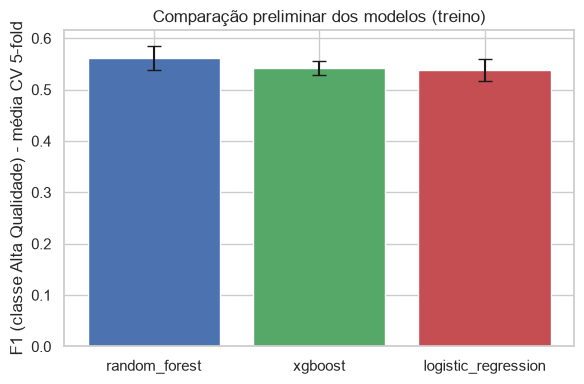

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(cv_df["modelo"], cv_df["f1_mean"], yerr=cv_df["f1_std"], capsize=5,
       color=["#4C72B0", "#55A868", "#C44E52"])
ax.set_ylabel("F1 (classe Alta Qualidade) - média CV 5-fold")
ax.set_title("Comparação preliminar dos modelos (treino)")
plt.tight_layout()
plt.savefig(f"{RESULTS}/05_cv_f1_comparison.png", dpi=150)
plt.show()

## Resultado preliminar

Na validação cruzada do treino, o **Random Forest** apresentou o melhor F1
médio (~0,56), seguido por XGBoost (~0,54) e Regressão Logística (~0,54) - uma
vantagem pequena mas consistente do Random Forest, sugerindo que relações
não-lineares/interações entre variáveis (ex.: álcool e densidade) importam
mais do que efeitos puramente lineares. A confirmação final e a comparação
completa de métricas (precisão, recall, ROC-AUC, matriz de confusão) no
conjunto de teste, nunca visto pelos modelos, são feitas no notebook 03.